In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Libraries**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd


train_df = pd.read_csv("fashion-mnist_train.csv")
test_df  = pd.read_csv("fashion-mnist_test.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'fashion-mnist_train.csv'

**Load and Explore Dataset**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


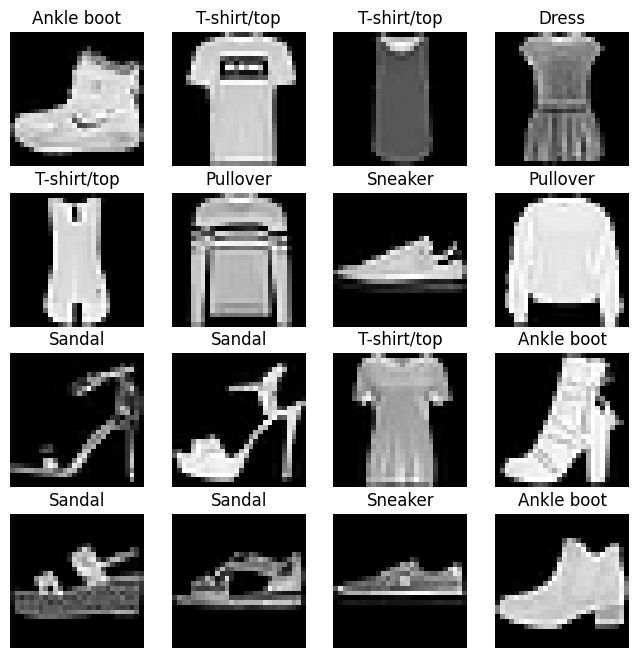

In [8]:
# Load Fashion-MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

# Display dataset shapes
print("Training set:", train_images.shape, train_labels.shape)
print("Test set:", test_images.shape, test_labels.shape)

# Class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize a few samples
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.show()


# Veds Implementation**

Loading data...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Original Full Dataset (60000 total) ---
T-shirt/top : 6000 (10.0%)
Trouser     : 6000 (10.0%)
Pullover    : 6000 (10.0%)
Dress       : 6000 (10.0%)
Coat        : 6000 (10.0%)
Sandal      : 6000 (10.0%)
Shirt       : 6000 (10.0%)
Sneaker     : 6000 (10.0%)
Bag         : 6000 (10.0%)
Ankle boot  : 6000 (10.0%)

--- Training Set (90%) (54000 total) ---
T-shirt/top : 5400 (10.0%)
Trouser     : 5400 (10.0%)
Pullover    : 5400 (10.0%)
Dress       : 5400 (10.0%)
Coat        : 5400 (10.0%)
Sandal      : 5400 (10.0%)
Shirt       : 5400 (10.0%)
Sneaker     : 5400 (10.0%)
Bag         : 5400 (10.0%)
Ankle boot  : 5400 (10.0%)

--- Validation Set (10%) (6000 total) ---
T-shirt/top : 600 (10.0%)
Trouser     : 600 (10.0%)
Pullover    : 600 (10.0%)
Dress       : 600 (10.0%)
Coat        : 600 (10.

/tmp/ipython-input-3471418926.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts_val, palette="viridis")


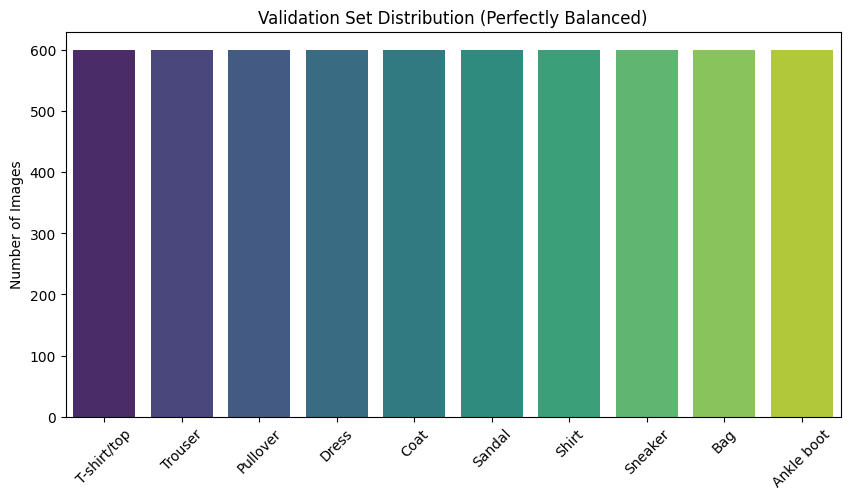

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Load the Data (Defines y_full)
# ==========================================
print("Loading data...")
# This line was missing from your current run
(X_full, y_full), (X_test, y_test) = fashion_mnist.load_data()

# Split the data (Stratified)
# We must flatten X just to be consistent with previous steps, though not strictly needed for counting y
X_full_flat = X_full.reshape(X_full.shape[0], -1)

X_train, X_val, y_train, y_val = train_test_split(
    X_full_flat, y_full,
    test_size=0.1,
    random_state=42,
    stratify=y_full
)

# ==========================================
# 2. Count and Print
# ==========================================
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def print_class_counts(y_data, title):
    unique, counts = np.unique(y_data, return_counts=True)
    print(f"\n--- {title} ({len(y_data)} total) ---")
    for label, count in zip(unique, counts):
        percent = (count / len(y_data)) * 100
        print(f"{class_names[label]:<12}: {count} ({percent:.1f}%)")

# Check counts
print_class_counts(y_full, "Original Full Dataset")
print_class_counts(y_train, "Training Set (90%)")
print_class_counts(y_val, "Validation Set (10%)")

# ==========================================
# 3. Visualize Validation Distribution
# ==========================================
unique_val, counts_val = np.unique(y_val, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=counts_val, palette="viridis")
plt.title("Validation Set Distribution (Perfectly Balanced)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Helper: Plot Confusion Matrix ---
def plot_confusion_matrix(y_true, y_pred, title):
    class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# --- 1. Load & Preprocess Data ---
print("Loading and flattening data...")
(X_full, y_full), (X_test, y_test) = fashion_mnist.load_data()

# Flatten: (60000, 28, 28) -> (60000, 784)
X_full_flat = X_full.reshape(X_full.shape[0], -1).astype('float32') / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

# Split Training into Train (90%) and Validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_full_flat, y_full, test_size=0.1, random_state=42, stratify=y_full
)

print(f"Train shape: {X_train.shape} | Val shape: {X_val.shape}")

Loading and flattening data...
Train shape: (54000, 784) | Val shape: (6000, 784)


## Random Forrest

--- Training Random Forest ---
Training time: 89.28 seconds

Random Forest Accuracy: 0.8744

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1000
           1       0.99      0.96      0.98      1000
           2       0.76      0.81      0.78      1000
           3       0.87      0.90      0.89      1000
           4       0.77      0.81      0.79      1000
           5       0.98      0.96      0.97      1000
           6       0.71      0.58      0.64      1000
           7       0.93      0.95      0.94      1000
           8       0.96      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



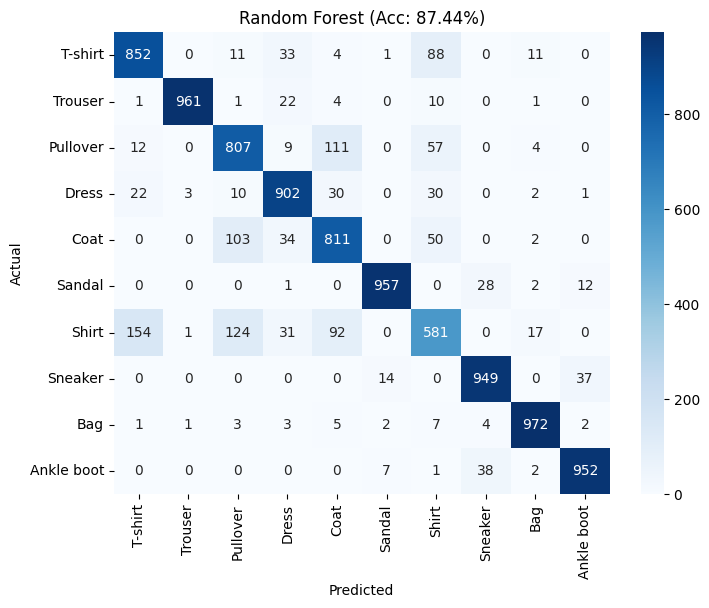

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

print("--- Training Random Forest ---")
start_time = time.time()

# n_jobs=-1 uses all CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print(f"Training time: {time.time() - start_time:.2f} seconds")

# Predictions
rf_pred = rf_model.predict(X_test_flat)
rf_acc = accuracy_score(y_test, rf_pred)

# --- Output Metrics & Graphs ---
print(f"\nRandom Forest Accuracy: {rf_acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

# Plot Confusion Matrix
plot_confusion_matrix(y_test, rf_pred, f"Random Forest (Acc: {rf_acc:.2%})")

## XGBoost Implementation

XGB with PCA Impact: High Why: The 28x28 grid (784 pixels) contains a lot of "dead space" (black background) and correlated pixels. This noise confuses tree models. Principal Component Analysis (PCA) compresses the data into fewer, meaningful features.

How to do it: Instead of feeding 784 columns, we feed the top ~50 components that explain 95% of the variance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 1. Data Setup & PCA
# ==========================================
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Loading and flattening data...")
(X_full, y_full), (X_test, y_test) = fashion_mnist.load_data()
X_full_flat = X_full.reshape(X_full.shape[0], -1).astype('float32') / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

# Split Validation Set
X_train, X_val, y_train, y_val = train_test_split(
    X_full_flat, y_full, test_size=0.1, random_state=42, stratify=y_full
)

# Apply PCA (95% Variance)
print("Applying PCA...")
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test_flat)

# ==========================================
# 2. Train XGBoost
# ==========================================
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=6,
    tree_method='hist',
    device='cuda',         # Change to 'cpu' if needed
    eval_metric=["mlogloss"],
    early_stopping_rounds=10,
    random_state=42
)

xgb_model.fit(
    X_train_pca, y_train,
    eval_set=[(X_train_pca, y_train), (X_val_pca, y_val)],
    verbose=False
)

# ==========================================
# 3. Calculate Metrics
# ==========================================
# Predict using the best model found during early stopping
y_pred = xgb_model.predict(X_test_pca)
final_acc = accuracy_score(y_test, y_pred)

# ==========================================
# 4. Visualization
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# --- Graph 1: Training History (Log Loss) ---
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

ax[0].plot(x_axis, results['validation_0']['mlogloss'], label='Train')
ax[0].plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
ax[0].axvline(xgb_model.best_iteration, color='r', linestyle='--', label='Early Stop Point')
ax[0].set_title('Model Training: Log Loss vs Epochs')
ax[0].set_ylabel('Log Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()
ax[0].grid(True)

# --- Graph 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names, yticklabels=class_names)
ax[1].set_title(f'Confusion Matrix (Test Accuracy: {final_acc:.2%})')
ax[1].set_ylabel('Actual Label')
ax[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ==========================================
# 5. FINAL RESULTS PRINT
# ==========================================
print("\n" + "="*30)
print("       FINAL MODEL RESULTS       ")
print("="*30)
print(f"Best Iteration (Epoch): {xgb_model.best_iteration}")
print(f"Number of PCA Components: {pca.n_components_}")
print(f"Final Test Accuracy:      {final_acc:.4f} ({final_acc*100:.2f}%)")
print("="*30)
print("-" * 30)
print(f"Features BEFORE PCA: {X_train.shape[1]}") # Should be 784
print(f"Features AFTER PCA:  {X_train_pca.shape[1]}") # Usually ~187
print("-" * 30)

Loading and flattening data...
Applying PCA...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [05:56:03] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [05:56:03] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


KeyboardInterrupt: 

## When both models are combined and soft vote is taken

In [ ]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# Define the base models (use your best params here)
clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2 = XGBClassifier(n_estimators=300, learning_rate=0.1, device='cuda')

# Combine them
ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2)],
    voting='soft' # 'soft' uses predicted probabilities, 'hard' uses class labels
)

ensemble_model.fit(X_train, y_train)
print(f"Ensemble Accuracy: {ensemble_model.score(X_test_flat, y_test)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:03:27] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:03:27] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import learning_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# --- [Your Existing Setup] ---
# (Assuming ensemble_model is already defined as in your snippet)

print("Training Ensemble...")
ensemble_model.fit(X_train, y_train)
acc = ensemble_model.score(X_test_flat, y_test)
print(f"Ensemble Accuracy: {acc:.4f}")

# ==========================================
# VISUALIZATION 1: Confusion Matrix
# Shows exactly which classes are being confused
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay.from_estimator(
    ensemble_model,
    X_test_flat,
    y_test,
    cmap=plt.cm.Blues,
    normalize='true', # Normalizes to show percentages (0.0 to 1.0)
    ax=ax
)
ax.set_title(f"Ensemble Confusion Matrix (Acc: {acc:.2%})")
plt.show()

# ==========================================
# VISUALIZATION 2: Learning Curve (Error Graph)
# Shows if adding more data helps (Bias vs Variance)
# ==========================================
print("\nGenerating Learning Curve (this may take a moment)...")

train_sizes, train_scores, test_scores = learning_curve(
    ensemble_model,
    X_train, y_train,
    cv=3,              # 3-fold cross-validation
    n_jobs=-1,         # Use all CPU cores
    train_sizes=np.linspace(0.1, 1.0, 5), # Test at 10%, 30%... 100% of data
    scoring='accuracy'
)

# Calculate mean and standard deviation for shading
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")

# Add shading for variance
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Ensemble Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid()
plt.show()

Training Ensemble...


NameError: name 'ensemble_model' is not defined

#Aayushi's Implementation**

**Data Preprocessing**

In [7]:
# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape for neural network
X_train = train_images.reshape((train_images.shape[0], 28, 28, 1))
X_test = test_images.reshape((test_images.shape[0], 28, 28, 1))

# One-hot encode labels
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)


** MLP**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
3000/3000 - 11s - 4ms/step - accuracy: 0.8199 - loss: 0.5022 - val_accuracy: 0.8529 - val_loss: 0.4137
Epoch 2/50
3000/3000 - 8s - 3ms/step - accuracy: 0.8612 - loss: 0.3776 - val_accuracy: 0.8670 - val_loss: 0.3634
Epoch 3/50
3000/3000 - 7s - 2ms/step - accuracy: 0.8741 - loss: 0.3403 - val_accuracy: 0.8743 - val_loss: 0.3535
Epoch 4/50
3000/3000 - 8s - 3ms/step - accuracy: 0.8824 - loss: 0.3154 - val_accuracy: 0.8750 - val_loss: 0.3442
Epoch 5/50
3000/3000 - 9s - 3ms/step - accuracy: 0.8897 - loss: 0.2956 - val_accuracy: 0.8801 - val_loss: 0.3317
Epoch 6/50
3000/3000 - 8s - 3ms/step - accuracy: 0.8938 - loss: 0.2827 - val_accuracy: 0.8860 - val_loss: 0.3141
Epoch 7/50
3000/3000 - 8s - 3ms/step - accuracy: 0.8992 - loss: 0.2694 - val_accuracy: 0.8763 - val_loss: 0.3489
Epoch 8/50
3000/3000 - 7s - 2ms/step - accuracy: 0.9014 - loss: 0.2590 - val_accuracy: 0.8864 - val_loss: 0.3254
Epoch 9/50
3000/3000 - 8s - 3ms/step - accuracy: 0.9068 - loss: 0.2473 - val_accuracy: 0.8857 -

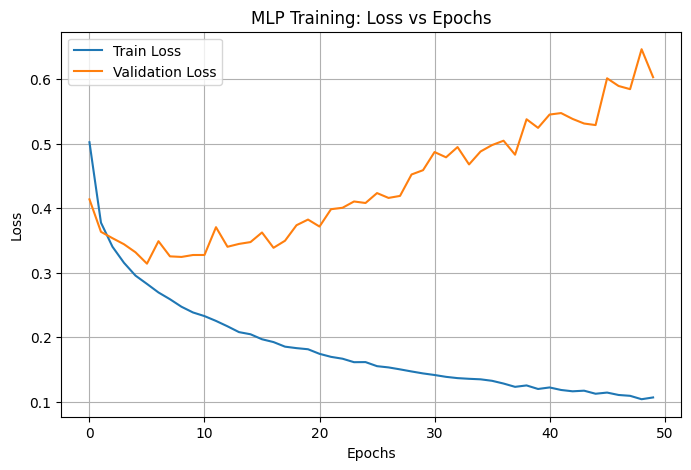

In [8]:
mlp_model = models.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mlp_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

mlp_history = mlp_model.fit(X_train, y_train, epochs=50,
                            validation_split=0.2, batch_size=16, verbose=2)

mlp_test_loss, mlp_test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"MLP Test Accuracy: {mlp_test_acc:.4f}")

# --- Graph: MLP Training History (Loss) ---
epochs = range(len(mlp_history.history['loss']))

plt.figure(figsize=(8,5))

plt.plot(epochs, mlp_history.history['loss'], label='Train Loss')
plt.plot(epochs, mlp_history.history['val_loss'], label='Validation Loss')

plt.title('MLP Training: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_mlp(hidden_units=256, dropout_rate=0.3, learning_rate=0.001, activation="relu"):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(hidden_units, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units//2, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


mlp_model = build_mlp(
    hidden_units=512,
    dropout_rate=0.4,
    learning_rate=0.0005,
    activation="relu"
)

history_mlp = mlp_model.fit(
    X_train.reshape(-1, 28, 28), y_train,
    validation_split=0.1,
    batch_size=128,
    epochs=20
)

test_loss, test_acc = mlp_model.evaluate(X_test.reshape(-1, 28, 28), y_test)
print("MLP Test Accuracy:", test_acc)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6847 - loss: 0.8891 - val_accuracy: 0.8410 - val_loss: 0.4485
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.4642 - val_accuracy: 0.8622 - val_loss: 0.3768
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8538 - loss: 0.4046 - val_accuracy: 0.8642 - val_loss: 0.3639
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8631 - loss: 0.3760 - val_accuracy: 0.8710 - val_loss: 0.3451
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8700 - loss: 0.3554 - val_accuracy: 0.8747 - val_loss: 0.3376
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8750 - loss: 0.3389 - val_accuracy: 0.8818 - val_loss: 0.3209
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8833 - loss: 0.3240 - val_accuracy: 0.8830 - val_loss: 0.3216
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.3214 - val_accuracy: 0.

In [11]:
y_pred_mlp = mlp_model.predict(X_test)
y_pred_mlp_labels = np.argmax(y_pred_mlp, axis=1)

print("\nMLP Classification Report:")
print(classification_report(test_labels, y_pred_mlp_labels, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

MLP Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.88      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.83      0.81      1000
       Dress       0.86      0.91      0.89      1000
        Coat       0.82      0.81      0.82      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt       0.77      0.64      0.70      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



**CNN Model**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
3000/3000 - 15s - 5ms/step - accuracy: 0.7957 - loss: 0.5612 - val_accuracy: 0.8665 - val_loss: 0.3568
Epoch 2/50
3000/3000 - 9s - 3ms/step - accuracy: 0.8589 - loss: 0.3904 - val_accuracy: 0.8827 - val_loss: 0.3178
Epoch 3/50
3000/3000 - 10s - 3ms/step - accuracy: 0.8744 - loss: 0.3439 - val_accuracy: 0.8907 - val_loss: 0.2883
Epoch 4/50
3000/3000 - 10s - 3ms/step - accuracy: 0.8823 - loss: 0.3183 - val_accuracy: 0.8965 - val_loss: 0.2782
Epoch 5/50
3000/3000 - 9s - 3ms/step - accuracy: 0.8896 - loss: 0.2977 - val_accuracy: 0.9007 - val_loss: 0.2673
Epoch 6/50
3000/3000 - 10s - 3ms/step - accuracy: 0.8954 - loss: 0.2842 - val_accuracy: 0.8965 - val_loss: 0.2791
Epoch 7/50
3000/3000 - 10s - 3ms/step - accuracy: 0.8968 - loss: 0.2731 - val_accuracy: 0.9087 - val_loss: 0.2466
Epoch 8/50
3000/3000 - 9s - 3ms/step - accuracy: 0.9021 - loss: 0.2630 - val_accuracy: 0.9095 - val_loss: 0.2522
Epoch 9/50
3000/3000 - 9s - 3ms/step - accuracy: 0.9052 - loss: 0.2550 - val_accuracy: 0.90

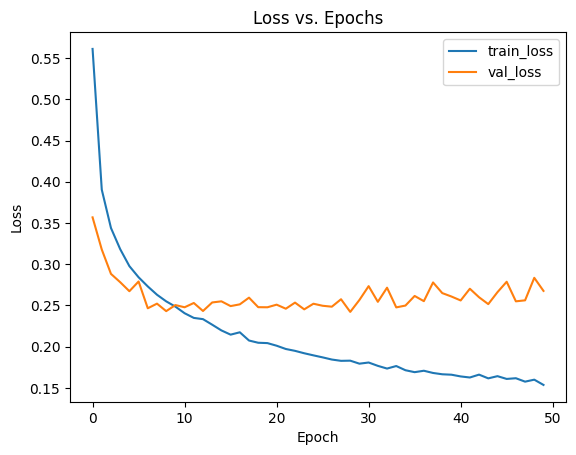

In [12]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 2. Compile the Model
cnn_model.compile(optimizer='adamw',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Train the Model
cnn_history = cnn_model.fit(X_train, y_train, epochs= 50,
                            validation_split=0.2, batch_size=16, verbose=2)

# 4. Evaluate the Model
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

# 5. Plot training & validation LOSS vs. Epochs
plt.plot(cnn_history.history['loss'], label='train_loss')
plt.plot(cnn_history.history['val_loss'], label='val_loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

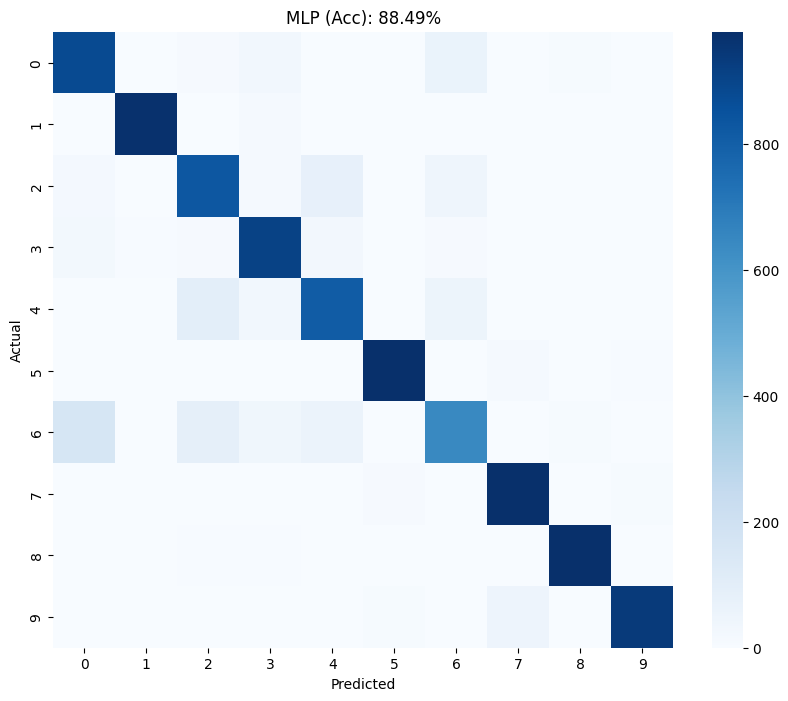

In [13]:
cm = confusion_matrix(test_labels, y_pred_mlp_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title(f"MLP (Acc): {mlp_test_acc:.2%}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
def build_cnn(num_filters=32, kernel_size=3, dense_units=128, dropout_rate=0.3, learning_rate=0.001):
    model = models.Sequential([
        layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        layers.Conv2D(num_filters, (kernel_size, kernel_size), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Conv2D(num_filters*2, (kernel_size, kernel_size), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn_model = build_cnn(
    num_filters=32,
    kernel_size=3,
    dense_units=128,
    dropout_rate=0.4,
    learning_rate=0.001
)

history_cnn = cnn_model.fit(
    X_train.reshape(-1, 28, 28),
    y_train,
    validation_split=0.1,
    batch_size=128,
    epochs=15
)

test_loss, test_acc = cnn_model.evaluate(X_test.reshape(-1, 28, 28), y_test)
print("CNN Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6927 - loss: 0.8514 - val_accuracy: 0.8648 - val_loss: 0.3631
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8637 - loss: 0.3860 - val_accuracy: 0.8867 - val_loss: 0.3051
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8842 - loss: 0.3257 - val_accuracy: 0.8925 - val_loss: 0.2781
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8965 - loss: 0.2886 - val_accuracy: 0.8962 - val_loss: 0.2831
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9024 - loss: 0.2675 - val_accuracy: 0.9095 - val_loss: 0.2442
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9103 - loss: 0.2446 - val_accuracy: 0.9053 - val_loss: 0.2518
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9159 - loss: 0.2326 - val_accuracy: 0.9138 - val_loss: 0.2305
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9224 - loss: 0.2155 - val_accuracy: 0

In [15]:
y_pred_cnn = cnn_model.predict(X_test.reshape(-1,28,28,1))
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

print("\nCNN Classification Report:")
print(classification_report(test_labels, y_pred_cnn_labels, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

CNN Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.92      0.79      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.92      0.81      0.86      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.86      0.88      0.87      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.69      0.85      0.76      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



**Confusion Matrix and Classification Report**

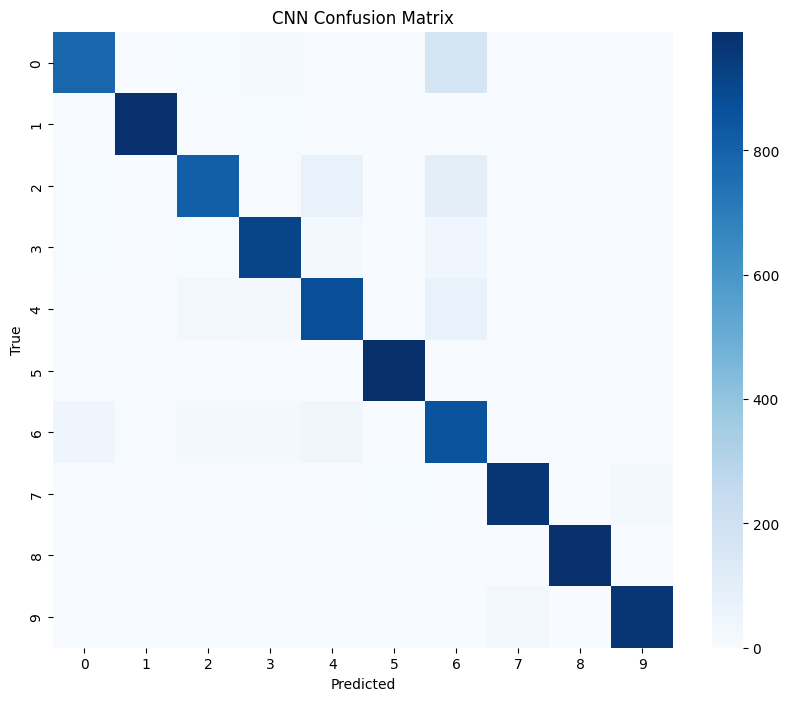

In [16]:


cm = confusion_matrix(test_labels, y_pred_cnn_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


ROC Curve

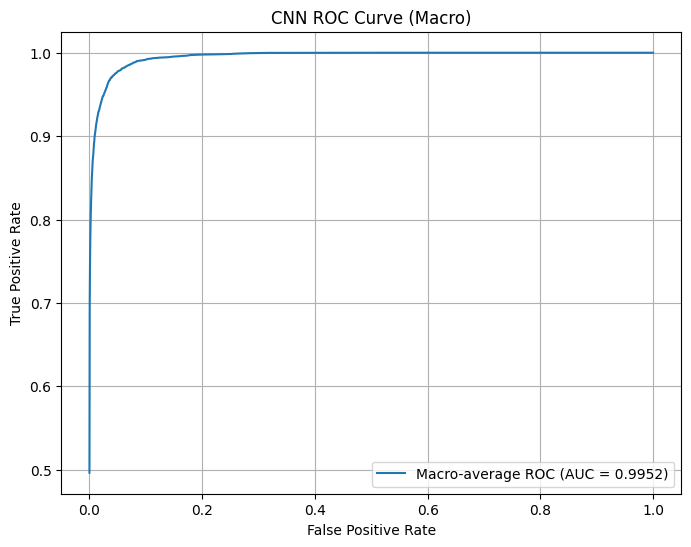

In [17]:
# Binarize labels
y_test_bin = label_binarize(test_labels, classes=range(10))

# Compute ROC curve & AUC for CNN
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_cnn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= 10
roc_auc_macro = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {roc_auc_macro:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve (Macro)")
plt.legend()
plt.grid()
plt.show()


**Dimensionality Reduction (PCA / t-SNE)**

PCA reduced shape: (2000, 50)
t-SNE reduced shape: (2000, 2)


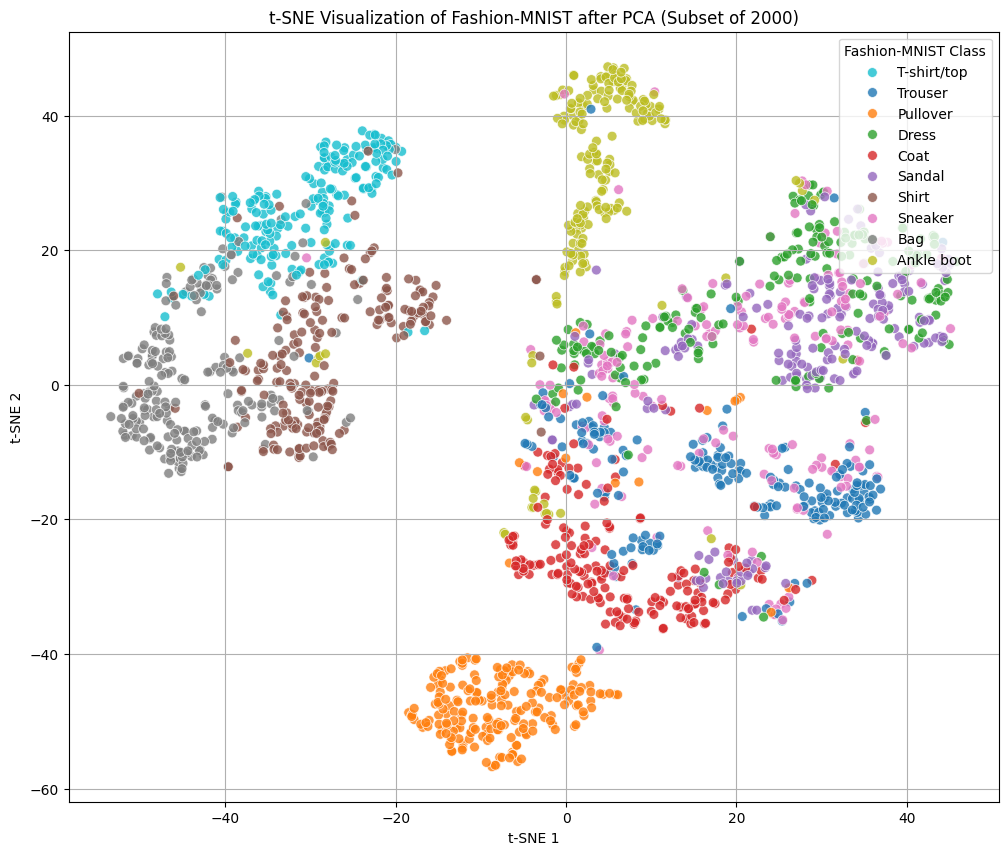

In [10]:

fashion_mnist_labels = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]


# Flatten images: (60000, 28, 28) → (60000, 784)
X_flat = train_images.reshape((60000, -1))

subset = 2000
X_small = X_flat[:subset]
y_small = train_labels[:subset]

pca_model = PCA(n_components=50, random_state=42)
X_pca = pca_model.fit_transform(X_small)
print("PCA reduced shape:", X_pca.shape)

tsne_model = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne_model.fit_transform(X_pca)

print("t-SNE reduced shape:", X_tsne.shape)

plt.figure(figsize=(10,8))
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y_small,
    palette='tab10',
    s=50,
    alpha=0.8,
    legend='full'
)

plt.legend(
    loc='upper right',
    labels=fashion_mnist_labels,
    title='Fashion-MNIST Class'
)

plt.title("t-SNE Visualization of Fashion-MNIST after PCA (Subset of 2000)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()

This plot shows t-SNE applied to Fashion-MNIST features after PCA.
Each point is an image; each color is a clothing class.

t-SNE groups similar items together, so tight clusters mean the images in that class look visually alike.

Well-separated clusters = distinct item types (e.g., shoes vs. bags).

Overlapping clusters = visually similar classes (e.g., shirts, pullovers, coats).

PCA was used first to reduce noise and speed up t-SNE.

Overall, the plot shows how Fashion-MNIST classes naturally cluster based on visual similarity.

**Auxiliary Task – Binary Grouping**

In [ ]:
# --- Auxiliary Task: Binary Grouping (Footwear vs Non-Footwear) ---

# Footwear classes: Sandal (5), Sneaker (7), Ankle Boot (9)
footwear_labels = [5, 7, 9]

# Binary labels: 1 = footwear, 0 = non-footwear
binary_train_labels = np.isin(train_labels, footwear_labels).astype(int)
binary_test_labels = np.isin(test_labels, footwear_labels).astype(int)

# Flatten images for classical ML models
X_train_flat = train_images.reshape(60000, -1)
X_test_flat  = test_images.reshape(10000, -1)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression Model
binary_model = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    n_jobs=-1
)

binary_model.fit(X_train_flat, binary_train_labels)
binary_preds = binary_model.predict(X_test_flat)

print("\nBinary Classification Report (Footwear vs Non-Footwear):")
print(classification_report(binary_test_labels, binary_preds,
                            target_names=['Non-Footwear', 'Footwear']))




Binary Classification Report (Footwear vs Non-Footwear):
              precision    recall  f1-score   support

Non-Footwear       1.00      1.00      1.00      7000
    Footwear       1.00      1.00      1.00      3000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



**ROC Curve**






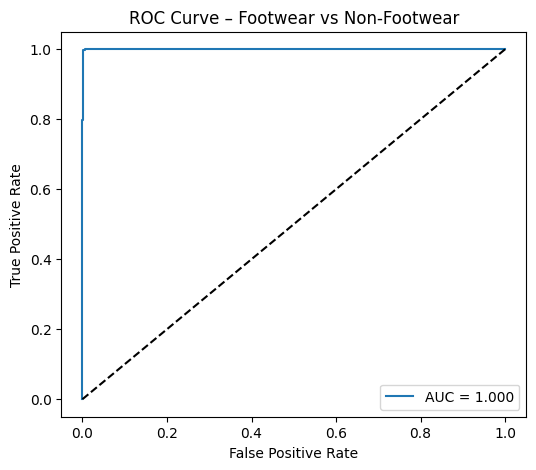

In [ ]:
from sklearn.metrics import roc_curve, auc

probs = binary_model.predict_proba(X_test_flat)[:,1]
fpr, tpr, thresholds = roc_curve(binary_test_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Footwear vs Non-Footwear")
plt.legend()
plt.show()


In [ ]:
print("=== Summary of Model Performance ===")
print(f"MLP Test Accuracy: {mlp_test_acc:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")


=== Summary of Model Performance ===
MLP Test Accuracy: 0.8836
CNN Test Accuracy: 0.9129
